In [1]:
# =============================================================================
# PARANDATUD ATEPP HELILOOJATE KLASSIFIKAATOR
# =============================================================================
# Parandused võrreldes 90.6% mudeliga:
# 1. Masked pooling (padding-tokeneid ei keskmistata)
# 2. Valideerimisandmestik + early stopping
# 3. WeightedRandomSampler klasside tasakaalustamiseks
# 4. Konservatiivne fine-tune (1 kiht, diferentseeritud lr)
# 5. K-Fold CV usaldusväärseks hindamiseks
# =============================================================================

# # 1. KESKKONNA SEADISTAMINE

!git clone https://github.com/wazenmai/MIDI-BERT.git
%cd MIDI-BERT

!pip install miditoolkit==0.1.14 mido==1.2.10 numpy transformers seaborn matplotlib scikit-learn pandas tqdm

import sys
import os
import zipfile

if os.path.basename(os.getcwd()) != "MIDI-BERT":
    %cd MIDI-BERT
sys.path.append(os.getcwd())

!mkdir -p Data/CP_data/tmp
!mkdir -p data_creation/prepare_data/dict
!python data_creation/prepare_data/dict/make_dict.py

if os.path.exists('data_creation/prepare_data/dict/CP.pkl'):
    print("EDUKAS: Sõnastik CP.pkl on loodud!")
else:
    print("VIGA: Sõnastikku ei tekkinud.")

Cloning into 'MIDI-BERT'...
remote: Enumerating objects: 1258, done.
remote: Counting objects: 100% (392/392), done.
remote: Compressing objects: 100% (254/254), done.
remote: Total 1258 (delta 171), reused 344 (delta 134), pack-reused 866 (from 1)
Receiving objects: 100% (1258/1258), 125.78 MiB | 9.17 MiB/s, done.
Resolving deltas: 100% (619/619), done.
/content/MIDI-BERT
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.5 MB/s eta 0:00:00
  Created wheel for miditoolkit: filename=miditoolkit-0.1.14-py3-none-any.whl size=19508 sha256=6c7725a5333629681b347d3a0249a07ac50116235ff0bc5183346ecb8ddc1ac3
  Stored in directory: /root/.cache/pip/wheels/f0/6e/d3/005b67a60d4a610bc9de6a19f02d205e7ce19972725138fff4
Successfully built miditoolkit
{'Bar': {'Bar New': 0, 'Bar Continue': 1, 'Bar <PAD>': 2, 'Bar <MASK>': 3}, 'Position': {'Position 1/16': 0, 'Position 2/16': 1, 'Position 3/16': 2, 'Position 4/16': 3, 'Position 5/16': 4, 'Position 6/16': 

In [2]:
# # 2. MUDELI LAADIMINE

from google.colab import drive
import torch
import torch.nn as nn
import pickle
import numpy as np
from transformers import BertConfig
from data_creation.prepare_data.model import CP
from MidiBERT.model import MidiBert

np.int = int
drive.mount('/content/drive')

ckpt_path = '/content/drive/MyDrive/LÕPUTÖÖ/MidiBERT-Piano/CP/pretrain_model.ckpt'
dict_path = 'data_creation/prepare_data/dict/CP.pkl'

with open(dict_path, 'rb') as f:
    e2w, w2e = pickle.load(f)

config = BertConfig(
    max_position_embeddings=512,
    position_embedding_type='relative_key_query',
    hidden_size=768, num_attention_heads=12, num_hidden_layers=12,
    pad_token_id=0, output_attentions=True, attn_implementation="eager"
)
config._attn_implementation = "eager"

midibert_base = MidiBert(bertConfig=config, e2w=e2w, w2e=w2e)
print("Laen eeltreenitud kaalusid...")
checkpoint = torch.load(ckpt_path, map_location='cpu')
state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint
clean_state_dict = {k.replace("module.", "").replace("midibert.", ""): v
                    for k, v in state_dict.items()}
midibert_base.load_state_dict(clean_state_dict, strict=False)
print("EDUKAS: Eeltreenitud MidiBERT on valmis!")

cp_model = CP(dict=dict_path)

Mounted at /content/drive
Laen eeltreenitud kaalusid...
EDUKAS: Eeltreenitud MidiBERT on valmis!


In [3]:
# # 3. KLASSIFIKAATORI ARHITEKTUUR (masked pooling)

class ComposerClassifier(nn.Module):
    """
    Parandatud klassifikaator:
    - MASKED POOLING: padding-tokeneid ei keskmistata
    - Dropout 0.3
    """
    def __init__(self, pretrained_midibert, num_classes):
        super().__init__()
        self.midibert = pretrained_midibert
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, input_ids, attn_mask, return_attentions=False):
        embs = [self.midibert.word_emb[i](input_ids[..., i])
                for i, _ in enumerate(self.midibert.classes)]
        emb_linear = self.midibert.in_linear(torch.cat([*embs], dim=-1))

        outputs = self.midibert.bert(
            inputs_embeds=emb_linear, attention_mask=attn_mask,
            output_hidden_states=True, output_attentions=True
        )

        # MASKED POOLING — keskmista AINULT mitte-padding tokenid
        hidden = outputs.last_hidden_state
        mask = attn_mask.unsqueeze(-1).float()
        summed = (hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1)
        pooled_output = summed / counts

        logits = self.classifier(self.dropout(pooled_output))
        if return_attentions:
            return logits, outputs.attentions
        return logits


target_labels = ['Bach', 'Mozart', 'Chopin', 'Debussy']
composer_to_id = {name: i for i, name in enumerate(target_labels)}
print(f"Klassid: {target_labels}")

Klassid: ['Bach', 'Mozart', 'Chopin', 'Debussy']


In [4]:
# # 4. ATEPP ANDMESTIKU ETTEVALMISTUS

import glob
import pandas as pd
from tqdm import tqdm

atepp_zip_path = "/content/drive/MyDrive/LÕPUTÖÖ/ATEPP.zip"
extract_dir = "/content/drive/MyDrive/LÕPUTÖÖ/ATEPP_dataset"

if not os.path.exists(extract_dir):
    print(f"Pakin {atepp_zip_path} lahti...")
    with zipfile.ZipFile(atepp_zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("ATEPP lahti pakitud!")
else:
    print("ATEPP juba lahti pakitud.")

csv_path = os.path.join(extract_dir, "ATEPP-metadata-1.2.csv")
df = pd.read_csv(csv_path)
df.columns = [col.lower() for col in df.columns]

# Indekseerime kõik MIDI failid kettalt
all_midis = glob.glob(os.path.join(extract_dir, "**", "*.mid"), recursive=True)
filename_to_real_path = {os.path.basename(p): p for p in all_midis}
print(f"MIDI faile kettal: {len(filename_to_real_path)}")

# Filtreerime 4 heliloojat
target_composers_search = ['bach', 'mozart', 'chopin', 'debussy']
filtered_data = []

for _, row in df.iterrows():
    if pd.isna(row['composer']) or pd.isna(row['midi_path']):
        continue
    composer_name = str(row['composer']).lower()
    for target in target_composers_search:
        if target in composer_name:
            csv_filename = os.path.basename(str(row['midi_path']))
            if csv_filename in filename_to_real_path:
                filtered_data.append({
                    'composer': target.capitalize(),
                    'midi_path': filename_to_real_path[csv_filename],
                    'composition_id': row.get('composition_id', None),
                    'track_duration': pd.to_numeric(row.get('track_duration', 0.0), errors='coerce')
                })
            break

filtered_df = pd.DataFrame(filtered_data)
salvestuste_arv = len(filtered_df)
# Loeme unikaalsed teosed composition_id põhjal
teoste_arv = filtered_df['composition_id'].nunique() if 'composition_id' in filtered_df.columns else "Teadmata"
# Arvutame kogukestuse tundides
tundide_arv = filtered_df['track_duration'].fillna(0.0).sum() / 3600

print("\n" + "="*50)
print(f"Salvestuste arv: {salvestuste_arv}")
print(f"Teoste arv: {teoste_arv}")
print(f"Kogu muusika pikkus (tundides): {tundide_arv:.1f}")
print("="*50 + "\n")
print(f"\nLugu leitud: {len(filtered_df)}")
print(filtered_df['composer'].value_counts())

ATEPP juba lahti pakitud.
MIDI faile kettal: 11699

Salvestuste arv: 4182
Teoste arv: 576
Kogu muusika pikkus (tundides): 302.2


Lugu leitud: 4182
composer
Chopin     1829
Bach       1318
Mozart      714
Debussy     321
Name: count, dtype: int64


In [ ]:
# # 5. PALA-TASANDI ANDMESTIKU KOOSTAMINE

import random
import copy
from collections import Counter, defaultdict
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

MAX_LEN = 512
MAX_SEGMENTS_PER_FILE = 15
PADDING_THRESHOLD = 0.7

# Koostame pala-tasandi andmestiku: (path, label, song_id)
# Kasutame kõiki faile — WeightedRandomSampler tasakaalustab klassid treeningu ajal
all_songs = []
song_id_counter = 0

for composer in target_labels:
    composer_files = filtered_df[filtered_df['composer'] == composer]['midi_path'].tolist()
    label_id = composer_to_id[composer]
    for f in composer_files:
        all_songs.append({'path': f, 'label': label_id, 'song_id': song_id_counter})
        song_id_counter += 1

all_paths = [s['path'] for s in all_songs]
all_labels = np.array([s['label'] for s in all_songs])
all_song_ids = np.array([s['song_id'] for s in all_songs])

print(f"Kokku palu: {len(all_songs)}")
for i, name in enumerate(target_labels):
    print(f"  {name}: {(all_labels == i).sum()}")

Kokku palu: 4182
  Bach: 1318
  Mozart: 714
  Chopin: 1829
  Debussy: 321


In [ ]:
# # 6. TOKENISEERIMINE (üks kord)
import gc
from IPython.display import clear_output
import logging
logging.getLogger().setLevel(logging.WARNING)
os.environ["TQDM_DISABLE"] = "1"

def tokenize_file(midi_path, label, song_id):
    """Tokeniseerib faili, filtreerib padding-raskeid segmente."""
    try:
        input_ids, _ = cp_model.prepare_data([midi_path], task='melody',
                                              max_len=MAX_LEN)
        out = []
        for seg in input_ids[:MAX_SEGMENTS_PER_FILE]:
            seg_arr = np.array(seg)
            padding_ratio = (seg_arr[:, 0] == 2).mean()
            if padding_ratio < PADDING_THRESHOLD:
                out.append((seg, label, song_id))
        return out
    except:
        return []


class ATEPPDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seg, label, song_id = self.data[idx]
        input_tensor = torch.tensor(seg, dtype=torch.long)
        attn_mask = (input_tensor[:, 0] != 2).float()
        return input_tensor, attn_mask, torch.tensor(label, dtype=torch.long), song_id


# Tokeniseerime kõik ühe korra ette
print("Tokeniseerin kõik palad (üks kord)...")
segments_by_sid = {}

for s in tqdm(all_songs, desc="Tokeniseerimine"):
    segs = tokenize_file(s['path'], s['label'], s['song_id'])
    segments_by_sid[s['song_id']] = segs
    if i % 50 == 0:
        gc.collect()
        if i > 0:
            clear_output(wait=True)
            print(f"Tokeniseeritud: {i}/{len(all_songs)}")

total_segs = sum(len(v) for v in segments_by_sid.values())
print(f"Segmente kokku: {total_segs}")

# Segmentide jaotus klasside kaupa
seg_label_counts = Counter()
for sid, segs in segments_by_sid.items():
    for _, label, _ in segs:
        seg_label_counts[label] += 1
for i, name in enumerate(target_labels):
    print(f"  {name}: {seg_label_counts[i]} segmenti")

Tokeniseerimine: 100%|██████████| 4182/4182 [1:08:50<00:00,  1.01it/s]

Segmente kokku: 19001
  Bach: 3655 segmenti
  Mozart: 4097 segmenti
  Chopin: 9932 segmenti
  Debussy: 1317 segmenti


In [ ]:
# # 7. TREENIMINE (üks 80/10/10 split, batch_size=64, mixed precision)

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, f1_score,
                              classification_report, balanced_accuracy_score)
from torch.cuda.amp import autocast, GradScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kasutan: {device}")

BATCH_SIZE = 64
EPOCHS_FROZEN = 10
EPOCHS_FT = 5
PATIENCE = 3

# Salvestame algse BERT-i kaalud
initial_state = copy.deepcopy(midibert_base.state_dict())

# Stratified split: 80% train, 10% valid, 10% test (pala-tasandil)
trainval_idx, test_idx = train_test_split(
    np.arange(len(all_songs)), test_size=0.1,
    stratify=all_labels, random_state=42)

trainval_labels = all_labels[trainval_idx]
train_idx, valid_idx = train_test_split(
    trainval_idx, test_size=0.111,  # 0.111 * 0.9 ≈ 0.1 kogu andmestikust
    stratify=trainval_labels, random_state=42)

train_sids = {all_song_ids[i] for i in train_idx}
valid_sids = {all_song_ids[i] for i in valid_idx}
test_sids = {all_song_ids[i] for i in test_idx}

print(f"Train palu: {len(train_idx)}, Valid palu: {len(valid_idx)}, Test palu: {len(test_idx)}")
for i, name in enumerate(target_labels):
    print(f"  {name}: train={(all_labels[train_idx] == i).sum()}, "
          f"valid={(all_labels[valid_idx] == i).sum()}, "
          f"test={(all_labels[test_idx] == i).sum()}")

# Segmentide filtreerimine
train_data = []
for sid in train_sids:
    train_data.extend(segments_by_sid.get(sid, []))
valid_data = []
for sid in valid_sids:
    valid_data.extend(segments_by_sid.get(sid, []))
test_data = []
for sid in test_sids:
    test_data.extend(segments_by_sid.get(sid, []))

print(f"\nSegmente — train: {len(train_data)}, valid: {len(valid_data)}, test: {len(test_data)}")

# WeightedRandomSampler
seg_labels = [s[1] for s in train_data]
class_counts = Counter(seg_labels)
print("Train segmentide jaotus:")
for cls_id, count in sorted(class_counts.items()):
    print(f"  {target_labels[cls_id]}: {count}")

sample_weights = [1.0 / class_counts[l] for l in seg_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(seg_labels),
                                 replacement=True)

train_loader = DataLoader(ATEPPDataset(train_data), batch_size=BATCH_SIZE, sampler=sampler)
valid_loader = DataLoader(ATEPPDataset(valid_data), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ATEPPDataset(test_data), batch_size=BATCH_SIZE, shuffle=False)


def evaluate_segments(model, loader):
    model.eval()
    preds, lbls = [], []
    with torch.no_grad():
        for inp, mask, lab, _ in loader:
            out = model(inp.to(device), mask.to(device))
            preds.extend(torch.argmax(out, 1).cpu().numpy())
            lbls.extend(lab.numpy())
    return preds, lbls


def evaluate_songs(model, loader):
    """Pala-tasandi hindamine: keskmistame segmentide logitid."""
    model.eval()
    song_logits = defaultdict(list)
    song_lbls = {}
    with torch.no_grad():
        for inp, mask, lab, sid in loader:
            out = model(inp.to(device), mask.to(device))
            for i, s in enumerate(sid):
                s = int(s)
                song_logits[s].append(out[i].cpu().numpy())
                song_lbls[s] = int(lab[i])
    preds, lbls = [], []
    for s, lst in song_logits.items():
        preds.append(int(np.argmax(np.mean(lst, axis=0))))
        lbls.append(song_lbls[s])
    return preds, lbls


# --- MUDELI TREENIMINE ---
classifier_model = ComposerClassifier(midibert_base, len(target_labels)).to(device)
scaler = GradScaler()

# === FAAS A: külmutatud BERT ===
for p in classifier_model.midibert.parameters():
    p.requires_grad = False
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, classifier_model.parameters()),
    lr=1e-3, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

best_balacc = 0
patience_counter = 0
print(f"\n--- Külmutatud baas ({EPOCHS_FROZEN} epohhi max) ---")
for epoch in range(EPOCHS_FROZEN):
    classifier_model.train()
    total_loss = 0
    for inp, mask, lab, _ in train_loader:
        inp, mask, lab = inp.to(device), mask.to(device), lab.to(device)
        optimizer.zero_grad()
        with autocast():
            out = classifier_model(inp, mask)
            loss = criterion(out, lab)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(classifier_model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    vp, vl = evaluate_segments(classifier_model, valid_loader)
    v_balacc = balanced_accuracy_score(vl, vp)
    print(f"  Ep {epoch+1}: valid_BalAcc={v_balacc:.3f}, "
          f"avg_loss={total_loss/len(train_loader):.4f}")

    if v_balacc > best_balacc:
        best_balacc = v_balacc
        patience_counter = 0
        torch.save(classifier_model.state_dict(), "best_frozen.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Frozen early stop ep{epoch+1}, best BalAcc={best_balacc:.3f}")
            break

classifier_model.load_state_dict(torch.load("best_frozen.pt"))

# === FAAS B: fine-tune viimane BERT kiht ===
print(f"\n--- Fine-tune (viimane kiht, diferentseeritud lr) ---")
for p in classifier_model.parameters():
    p.requires_grad = False
for p in classifier_model.classifier.parameters():
    p.requires_grad = True
n_layers = len(classifier_model.midibert.bert.encoder.layer)
for p in classifier_model.midibert.bert.encoder.layer[n_layers - 1].parameters():
    p.requires_grad = True

bert_params = [p for n, p in classifier_model.named_parameters()
               if 'midibert' in n and p.requires_grad]
clf_params = [p for n, p in classifier_model.named_parameters()
              if 'classifier' in n and p.requires_grad]
optimizer_ft = torch.optim.AdamW([
    {'params': bert_params, 'lr': 5e-6},
    {'params': clf_params, 'lr': 5e-5}
], weight_decay=0.05)

best_ft_balacc = best_balacc
patience_counter = 0
for epoch in range(EPOCHS_FT):
    classifier_model.train()
    total_loss = 0
    for inp, mask, lab, _ in train_loader:
        inp, mask, lab = inp.to(device), mask.to(device), lab.to(device)
        optimizer_ft.zero_grad()
        with autocast():
            out = classifier_model(inp, mask)
            loss = criterion(out, lab)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer_ft)
        torch.nn.utils.clip_grad_norm_(classifier_model.parameters(), 1.0)
        scaler.step(optimizer_ft)
        scaler.update()
        total_loss += loss.item()

    vp, vl = evaluate_segments(classifier_model, valid_loader)
    v_balacc = balanced_accuracy_score(vl, vp)
    print(f"  FT Ep {epoch+1}: valid_BalAcc={v_balacc:.3f}, "
          f"avg_loss={total_loss/len(train_loader):.4f}")

    if v_balacc > best_ft_balacc:
        best_ft_balacc = v_balacc
        patience_counter = 0
        torch.save(classifier_model.state_dict(), "best_ft.pt")
    else:
        patience_counter += 1
        if patience_counter >= 2:
            print(f"  FT early stop, best BalAcc={best_ft_balacc:.3f}")
            break

if os.path.exists("best_ft.pt"):
    classifier_model.load_state_dict(torch.load("best_ft.pt"))

Kasutan: cuda
Train palu: 3345, Valid palu: 418, Test palu: 419
  Bach: train=1054, valid=132, test=132
  Mozart: train=571, valid=71, test=72
  Chopin: train=1463, valid=183, test=183
  Debussy: train=257, valid=32, test=32

Segmente — train: 15330, valid: 1842, test: 1829
Train segmentide jaotus:
  Bach: 2917
  Mozart: 3337
  Chopin: 8037
  Debussy: 1039


/tmp/ipykernel_852/1466176906.py:102: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_852/1466176906.py:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



--- Külmutatud baas (10 epohhi max) ---
  Ep 1: valid_BalAcc=0.803, avg_loss=0.6879


/tmp/ipykernel_852/1466176906.py:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Ep 2: valid_BalAcc=0.831, avg_loss=0.5330


...

  FT Ep 3: valid_BalAcc=0.883, avg_loss=0.3473


/tmp/ipykernel_852/1466176906.py:175: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  FT Ep 4: valid_BalAcc=0.888, avg_loss=0.3170


/tmp/ipykernel_852/1466176906.py:175: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  FT Ep 5: valid_BalAcc=0.897, avg_loss=0.2855



ATEPP TULEMUSED
Segment-tasand: Acc=0.902, BalAcc=0.896
Pala-tasand:    Acc=0.938 | BalAcc=0.945 | F1=0.931

              precision    recall  f1-score   support

        Bach      0.941     0.970     0.955       132
      Mozart      0.875     0.972     0.921        72
      Chopin      0.976     0.902     0.938       183
     Debussy      0.882     0.938     0.909        32

    accuracy                          0.938       419
   macro avg      0.919     0.945     0.931       419
weighted avg      0.941     0.938     0.938       419



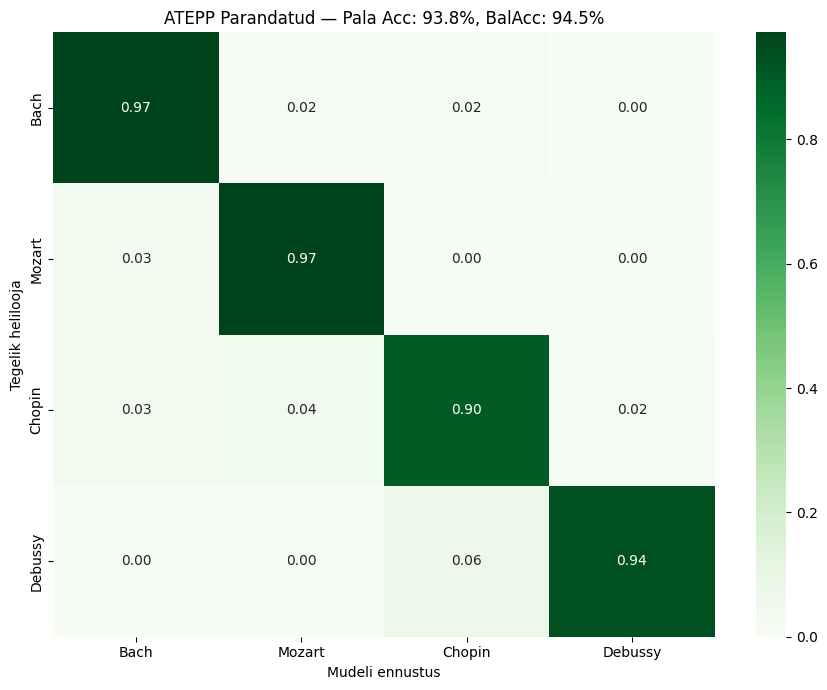

Mudel salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_parandatud_final.pt


In [ ]:
# # 8. TULEMUSED JA VISUALISEERIMINE

print("\n" + "="*70)
print("ATEPP TULEMUSED")
print("="*70)

# Segment-tasand
seg_preds, seg_lbls = evaluate_segments(classifier_model, test_loader)
seg_acc = accuracy_score(seg_lbls, seg_preds)
seg_balacc = balanced_accuracy_score(seg_lbls, seg_preds)
print(f"Segment-tasand: Acc={seg_acc:.3f}, BalAcc={seg_balacc:.3f}")

# Pala-tasand
sp, sl = evaluate_songs(classifier_model, test_loader)
pala_acc = accuracy_score(sl, sp)
pala_balacc = balanced_accuracy_score(sl, sp)
pala_f1 = f1_score(sl, sp, average='macro')

print(f"Pala-tasand:    Acc={pala_acc:.3f} | BalAcc={pala_balacc:.3f} | F1={pala_f1:.3f}")

print("\n" + classification_report(sl, sp, target_names=target_labels, digits=3))

# Confusion matrix
cm = confusion_matrix(sl, sp)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(9, 7))
sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=target_labels, yticklabels=target_labels)
plt.ylabel('Tegelik helilooja')
plt.xlabel('Mudeli ennustus')
plt.title(f'ATEPP Parandatud — Pala Acc: {pala_acc*100:.1f}%, BalAcc: {pala_balacc*100:.1f}%')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/LÕPUTÖÖ/atepp_parandatud_cm.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Salvestame mudeli
save_path = "/content/drive/MyDrive/LÕPUTÖÖ/atepp_parandatud_final.pt"
torch.save(classifier_model.state_dict(), save_path)
print(f"Mudel salvestatud: {save_path}")

In [ ]:
# # 9. HUVITAVAD EKSIMUSPALAD (attention rollout analüüsiks)

print("\n" + "="*70)
print("HUVITAVAD EKSIMUSPALAD ANALÜÜSIKS")
print("="*70)

sid_to_path = {s['song_id']: s['path'] for s in all_songs}
sid_to_label = {s['song_id']: s['label'] for s in all_songs}

classifier_model.eval()
song_logits_final = defaultdict(list)
with torch.no_grad():
    for inp, mask, lab, sid in test_loader:
        out = classifier_model(inp.to(device), mask.to(device))
        for i, s in enumerate(sid):
            s = int(s)
            song_logits_final[s].append(out[i].cpu().numpy())

print(f"\nEksimused:")
print(f"{'Fail':<30s} {'Tegelik':<10s} {'Ennustus':<10s} {'Kindlus'}")
print("-" * 70)

misclassified = []
for sid, logit_list in song_logits_final.items():
    mean_logit = np.mean(logit_list, axis=0)
    pred = int(np.argmax(mean_logit))
    true_label = sid_to_label[sid]

    if pred != true_label:
        probs = np.exp(mean_logit) / np.exp(mean_logit).sum()  # softmax
        fname = os.path.basename(sid_to_path[sid])
        true_name = target_labels[true_label]
        pred_name = target_labels[pred]
        conf = probs[pred]
        misclassified.append((fname, true_name, pred_name, conf, sid))
        print(f"  {fname:<30s} {true_name:<10s} {pred_name:<10s} {conf:.3f}")

print(f"\nKokku eksimusi: {len(misclassified)} / {len(song_logits_final)}")
print("\nNeed palad on kõige huvitavamad attention rollout'i jaoks!")


HUVITAVAD EKSIMUSPALAD ANALÜÜSIKS

Eksimused:
Fail                           Tegelik    Ennustus   Kindlus
----------------------------------------------------------------------
  09406.mid                      Chopin     Debussy    0.738
  09679.mid                      Chopin     Mozart     0.767
  09787.mid                      Chopin     Bach       0.520
  09795.mid                      Chopin     Bach       0.636
  09829.mid                      Chopin     Bach       0.505
  09833.mid                      Chopin     Bach       0.623
  09847.mid                      Chopin     Bach       0.549
  09897.mid                      Chopin     Debussy    0.693
  09905.mid                      Chopin     Mozart     0.714
  09909.mid                      Chopin     Mozart     0.961
  02312.mid                      Bach       Mozart     0.894
  02526.mid                      Bach       Chopin     0.556
  02575.mid                      Bach       Mozart     0.518
  10346.mid                 

In [ ]:
# # 10. KÕRGE KINDLUSEGA ÕIGESTI KLASSIFITSEERITUD PALAD

print("\n" + "="*70)
print("KÕRGE KINDLUSEGA ÕIGED ENNUSTUSED (rollout kontrollgrupiks)")
print("="*70)

from collections import defaultdict

top_correct = defaultdict(list)  # helilooja → [(fname, conf, sid)]

for sid, logit_list in song_logits_final.items():
    mean_logit = np.mean(logit_list, axis=0)
    pred = int(np.argmax(mean_logit))
    true_label = sid_to_label[sid]

    if pred == true_label:
        probs = np.exp(mean_logit) / np.exp(mean_logit).sum()
        fname = os.path.basename(sid_to_path[sid])
        true_name = target_labels[true_label]
        conf = probs[pred]
        top_correct[true_name].append((fname, conf, sid))

# Sorteeri iga helilooja kohta kindluse järgi ja võta top-3
print(f"\n{'Fail':<30s} {'Helilooja':<10s} {'Kindlus'}")
print("-" * 55)

for composer in target_labels:
    ranked = sorted(top_correct[composer], key=lambda x: -x[1])
    for fname, conf, sid in ranked[:3]:
        print(f"  {fname:<30s} {composer:<10s} {conf:.3f}")
    print()

print("Kasuta neid rollout'i kontrollgrupina!")


KÕRGE KINDLUSEGA ÕIGED ENNUSTUSED (rollout kontrollgrupiks)

Fail                           Helilooja  Kindlus
-------------------------------------------------------
  02177.mid                      Bach       1.000
  01911.mid                      Bach       1.000
  02728.mid                      Bach       1.000

  05225.mid                      Mozart     0.998
  10775.mid                      Mozart     0.998
  05453.mid                      Mozart     0.998

  09537.mid                      Chopin     0.999
  11086.mid                      Chopin     0.999
  09858.mid                      Chopin     0.999

  03121.mid                      Debussy    0.995
  03048.mid                      Debussy    0.993
  03061.mid                      Debussy    0.987

Kasuta neid rollout'i kontrollgrupina!
